In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 20.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 37.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      /tmp/pip-build-env-eb_vfktx/overlay/lib/python3.10/site-packages/setuptools/dist.py:332: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      /tmp/pip-build-env-eb_vfktx/overlay/lib/python3.10/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers ar

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import logging
from torch import cuda
from transformers import AutoTokenizer, AutoModel

logging.basicConfig(level=logging.ERROR)

# Select device
device = 'cuda' if cuda.is_available() else 'cpu'


In [ ]:
import pandas as pd

dataset_path = "/kaggle/input/final-about-column/final about column upsampled_data.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,Combined,About
0,I am a programmer and I love to solve challeng...,4
1,\nI have worked on the following projects duri...,4
2,More than 10+ experience in developing and int...,4
3,Experienced Software Engineer with a demonstra...,4
4,I am working around 6 years as Software Engine...,4


In [ ]:
import pandas as pd
from transformers import AutoTokenizer

# Create the labels based on Skills score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['About_Label'] = df['About'].apply(map_labels)

print("Mapped About_Label:")
print(df['About_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/About_Label.csv', index=False)


Mapped About_Label:
About_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  About  About_Label
0  I am a programmer and I love to solve challeng...      4            2
1  \nI have worked on the following projects duri...      4            2
2  More than 10+ experience in developing and int...      4            2
3  Experienced Software Engineer with a demonstra...      4            2
4  I am working around 6 years as Software Engine...      4            2


In [ ]:
from transformers import AutoTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the tokenizer for LastBERT (actual HF repo id)
tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

df = pd.read_csv("/kaggle/working/About_Label.csv")

# Function to tokenize the text using LastBERT tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'About_Label']].head())


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

0    [input_ids, token_type_ids, attention_mask]
1    [input_ids, token_type_ids, attention_mask]
2    [input_ids, token_type_ids, attention_mask]
3    [input_ids, token_type_ids, attention_mask]
4    [input_ids, token_type_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  About_Label
0  I am a programmer and I love to solve challeng...            2
1  \nI have worked on the following projects duri...            2
2  More than 10+ experience in developing and int...            2
3  Experienced Software Engineer with a demonstra...            2
4  I am working around 6 years as Software Engine...            2


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/About_Label.csv")  # This is your labeled data file

# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)

print(f"Files saved to {output_dir}:")
print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
Files saved to /kaggle/working/:
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# Load LastBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

# Define the custom PyTorch Dataset
class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the combined text and label for a specific index
        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['About_Label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check a batch from the train DataLoader
for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break  # Just to check one batch only


Input IDs: tensor([[  101,  3026,  4007,  ...,     0,     0,     0],
        [  101,  4007,  3992,  ...,     0,     0,     0],
        [  101, 13459,  1010,  ...,     0,     0,     0],
        ...,
        [  101,  2062,  2084,  ...,     0,     0,     0],
        [  101,  4007,  3992,  ...,     0,     0,     0],
        [  101,  1045,  2031,  ...,     0,     0,     0]])
Attention Mask: tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([1, 0, 1, 2, 0, 2, 2, 2, 2, 0, 1, 1, 2, 2, 0, 2])


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AdamW

# Define the LastBERT-based model
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()

        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True  # <-- THIS FIXES THE size mismatch
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through LastBERT
        output = self.lastbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        return output.logits

# Initialize the model
model = LastBERTClass(num_labels=3)  # Negative (0), Neutral (1), Positive (2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the loss function
criterion = nn.CrossEntropyLoss()

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)
print(model)


config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


LastBERTClass(
  (lastbert): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 384, padding_idx=0)
        (position_embeddings): Embedding(512, 384)
        (token_type_embeddings): Embedding(2, 384)
        (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-5): 6 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=384, out_features=

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
import torch.nn as nn
from sklearn.model_selection import train_test_split

# Define the custom Dataset class to handle the text and labels
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare data
texts = df['Combined'].tolist()
labels = df['About_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Create dataloaders for batching
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)  # increased batch size
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the LastBERT model class
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()

        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True
        )

    def forward(self, input_ids, attention_mask):
        output = self.lastbert(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits

# Initialize the model
model = LastBERTClass(num_labels=3)

# Use multiple GPUs with DataParallel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

# Set up optimizer and loss
optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training and evaluation loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=19):
    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        model.eval()
        correct_val = 0
        total_val = 0
        running_val_loss = 0.0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs

                loss = criterion(logits, labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# Train the LastBERT model on multiple GPUs
train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=19)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Epoch 1/19
Training Loss: 1.0995, Training Accuracy: 0.3480
Validation Loss: 1.0847, Validation Accuracy: 0.3665
Epoch 2/19
Training Loss: 1.0788, Training Accuracy: 0.4379
Validation Loss: 1.0675, Validation Accuracy: 0.5825
Epoch 3/19
Training Loss: 1.0614, Training Accuracy: 0.5456
Validation Loss: 1.0462, Validation Accuracy: 0.6484
Epoch 4/19
Training Loss: 1.0376, Training Accuracy: 0.6037
Validation Loss: 1.0163, Validation Accuracy: 0.6426
Epoch 5/19
Training Loss: 1.0028, Training Accuracy: 0.6127
Validation Loss: 0.9741, Validation Accuracy: 0.6530
Epoch 6/19
Training Loss: 0.9554, Training Accuracy: 0.6283
Validation Loss: 0.9194, Validation Accuracy: 0.6561
Epoch 7/19
Training Loss: 0.8992, Training Accuracy: 0.6391
Validation Loss: 0.8587, Validation Accuracy: 0.6688
Epoch 8/19
Training Loss: 0.8405, Training Accuracy: 0.6529
Validation Loss: 0.8002, Validation Accuracy: 0.6859
Epoch 9/19
Training Loss: 0.7856, Training Accuracy: 0.6664
Validation Loss: 0.7491, Validation 

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='lastbert_model.pth', tokenizer_path='lastbert_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to distilroberta_model.pth
Tokenizer saved to distilroberta_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss, roc_auc_score
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.84      0.95      0.89       727
     Class 1       0.94      0.75      0.83       751
     Class 2       0.93      1.00      0.96       735

    accuracy                           0.90      2213
   macro avg       0.90      0.90      0.90      2213
weighted avg       0.90      0.90      0.90      2213

Hamming Loss: 0.1012


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


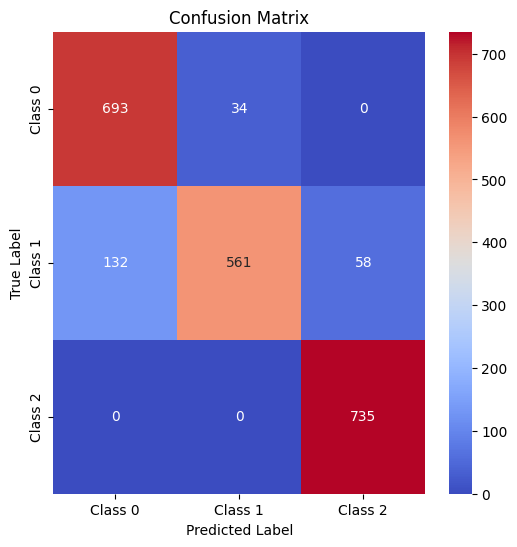

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# Plotting Confusion Matrix with different color
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=True,
                xticklabels=["Class 0","Class 1", "Class 2"],
                yticklabels=["Class 0","Class 1", "Class 2"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call the evaluate_model function to evaluate the model
evaluate_model(model, val_dataloader, device)


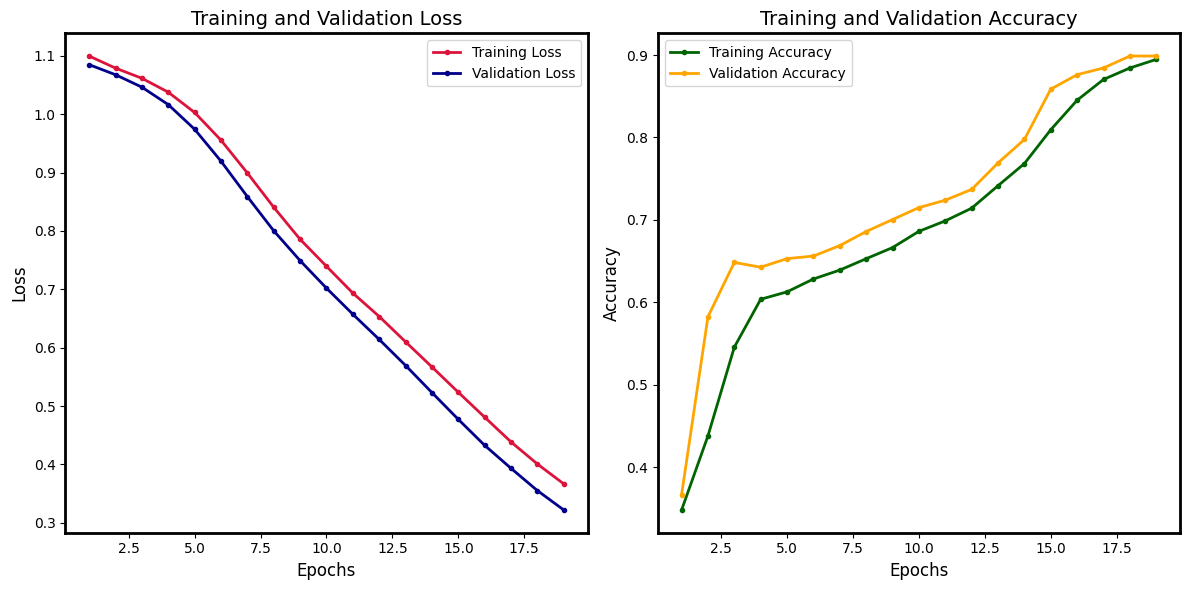

In [ ]:
import matplotlib.pyplot as plt

# Data for 19 epochs
epochs = list(range(1, 20))
train_loss = [
    1.0995, 1.0788, 1.0614, 1.0376, 1.0028, 0.9554, 0.8992, 0.8405, 0.7856,
    0.7394, 0.6935, 0.6534, 0.6100, 0.5670, 0.5236, 0.4809, 0.4385, 0.4007, 0.3667
]
val_loss = [
    1.0847, 1.0675, 1.0462, 1.0163, 0.9741, 0.9194, 0.8587, 0.8002, 0.7491,
    0.7020, 0.6573, 0.6141, 0.5695, 0.5231, 0.4772, 0.4327, 0.3933, 0.3552, 0.3220
]
train_accuracy = [
    0.3480, 0.4379, 0.5456, 0.6037, 0.6127, 0.6283, 0.6391, 0.6529, 0.6664,
    0.6861, 0.6988, 0.7142, 0.7415, 0.7683, 0.8094, 0.8452, 0.8704, 0.8843, 0.8947
]
val_accuracy = [
    0.3665, 0.5825, 0.6484, 0.6426, 0.6530, 0.6561, 0.6688, 0.6859, 0.7004,
    0.7149, 0.7239, 0.7370, 0.7691, 0.7976, 0.8586, 0.8762, 0.8843, 0.8988, 0.8988
]

# Set figure background color to white
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# --- Plot Loss ---
axs[0].plot(epochs, train_loss, label='Training Loss', color='crimson', linewidth=2, marker='o', markersize=3)
axs[0].plot(epochs, val_loss, label='Validation Loss', color='darkblue', linewidth=2, marker='o', markersize=3)
axs[0].set_title('Training and Validation Loss', fontsize=14)
axs[0].set_xlabel('Epochs', fontsize=12)
axs[0].set_ylabel('Loss', fontsize=12)
axs[0].legend()
axs[0].grid(False)

# Add deep black border
for spine in axs[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# --- Plot Accuracy ---
axs[1].plot(epochs, train_accuracy, label='Training Accuracy', color='darkgreen', linewidth=2, marker='o', markersize=3)
axs[1].plot(epochs, val_accuracy, label='Validation Accuracy', color='orange', linewidth=2, marker='o', markersize=3)
axs[1].set_title('Training and Validation Accuracy', fontsize=14)
axs[1].set_xlabel('Epochs', fontsize=12)
axs[1].set_ylabel('Accuracy', fontsize=12)
axs[1].legend()
axs[1].grid(False)

# Add deep black border
for spine in axs[1].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()
